# ⚙️ Install Requirements

In [1]:
# Use Terminal to install requirements.txt
#%pip install --upgrade pip  #optional
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 📦 Import Required Libraries

In [2]:
from itertools import count
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 📂 Load the Dataset

In [3]:
__path__ = "E:/Major Project/Dataset/"
csv_file = "heart_data.csv"

df = pd.read_csv(__path__ + csv_file)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (5000, 14)
   age  gender  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0   63       1   3       145   233    1        0      150      0      2.3   
1   37       1   2       130   250    0        1      187      0      3.5   
2   41       0   1       130   204    0        0      172      0      1.4   
3   56       1   1       120   236    0        1      178      0      0.8   
4   57       0   0       120   354    0        1      163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  


# 🔍 Exploratory Data Analysis (EDA)

## Missing Value Analysis


Missing values (count):
age         0
gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
--------------------

Missing values (%)
age         0.0
gender      0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64


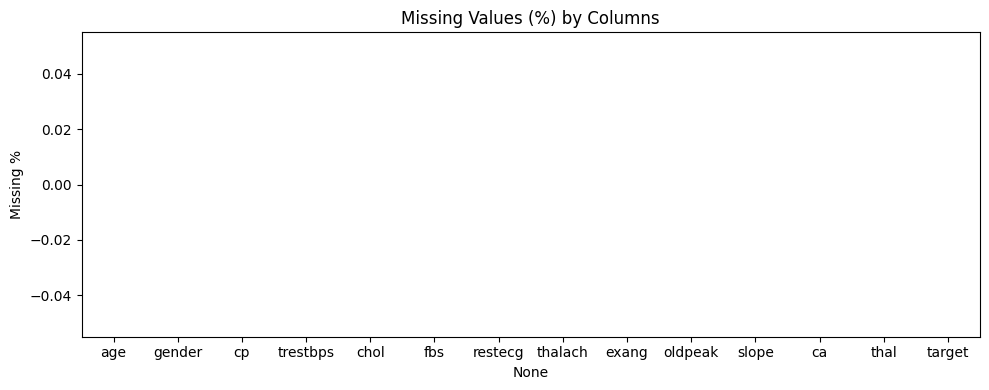

In [4]:
print("\nMissing values (count):")
print(df.isna().sum())

print("-"*20)

print("\nMissing values (%)")
print((df.isna().mean() * 100).round(2).sort_values(ascending=False))

plt.figure(figsize=(10,4))
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.title("Missing Values (%) by Columns")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()

## Target Class Distribution


Target balance (0=no disease, 1=disease):
        count
target       
1        2702
0        2298
--------------------
       proportion
target           
1          54.04%
0          45.96%


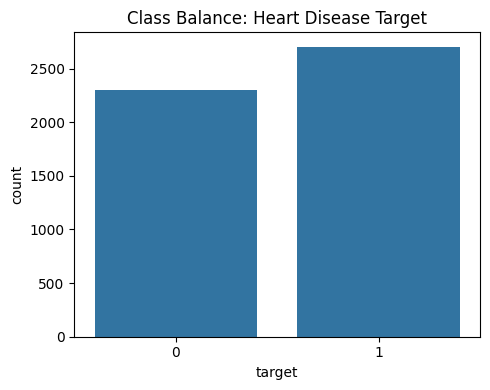

In [5]:
print("\nTarget balance (0=no disease, 1=disease):")
print(pd.DataFrame(df["target"].value_counts()))
print("-"* 20)
print(pd.DataFrame(df["target"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%"))

plt.figure(figsize=(5,4))
sns.countplot(x="target", data=df)
plt.title("Class Balance: Heart Disease Target")
plt.tight_layout()
plt.show()

## Age Distribution

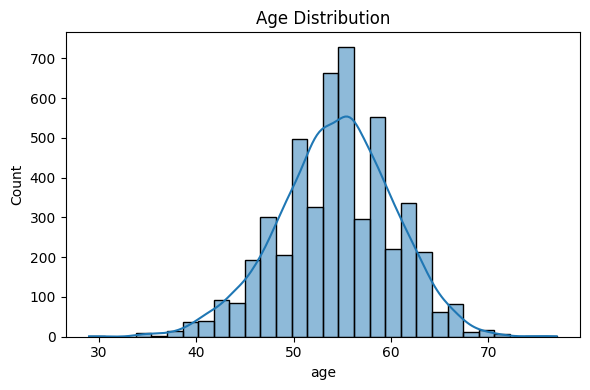

In [6]:
if "age" in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df["age"], bins=30, kde=True)
    plt.title("Age Distribution")
    plt.tight_layout()
    plt.show()

## Gender Distribution


Gender balance (0=FEMALE ♀️, 1=MALE ♂️):


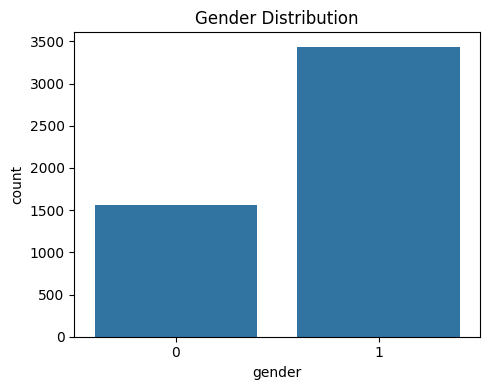

In [7]:
print("\nGender balance (0=FEMALE ♀️, 1=MALE ♂️):")
if "gender" in df.columns:
    plt.figure(figsize=(5,4))
    sns.countplot(x="gender", data=df)
    plt.title("Gender Distribution")
    plt.tight_layout()
    plt.show()

## Cholesterol & Blood Pressure Distribution

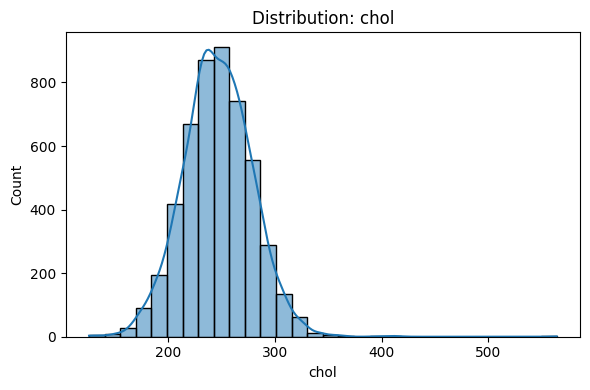

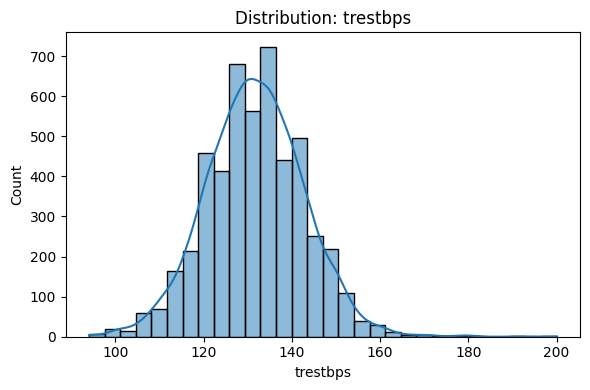

In [8]:
for col in ["chol", "trestbps"]:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Distribution: {col}")
        plt.tight_layout()
        plt.show()

## Chest Pain Type vs Heart Disease

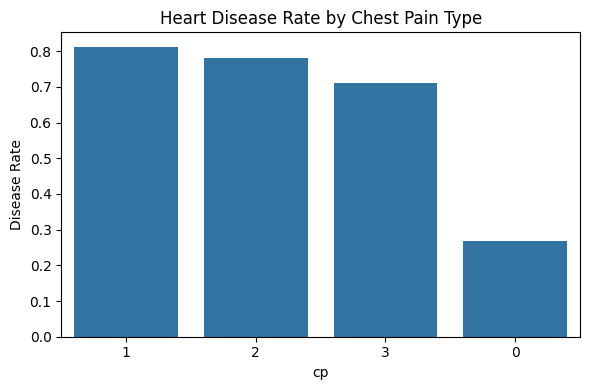

In [9]:
if "cp" in df.columns:
    cp_rate = df.groupby("cp")["target"].mean().sort_values(ascending=False)

    plt.figure(figsize=(6,4))
    sns.barplot(x=cp_rate.index.astype(str), y=cp_rate.values)
    plt.title("Heart Disease Rate by Chest Pain Type")
    plt.xlabel("cp")
    plt.ylabel("Disease Rate")
    plt.tight_layout()
    plt.show()

## Maximum Heart Rate vs Disease

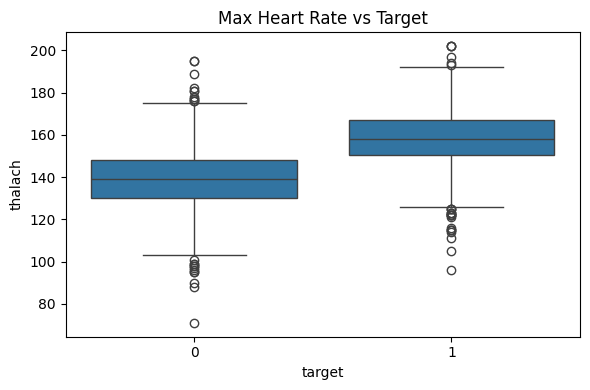

In [10]:
if "thalach" in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="target", y="thalach", data=df)
    plt.title("Max Heart Rate vs Target")
    plt.tight_layout()
    plt.show()

## Correlation Heatmap

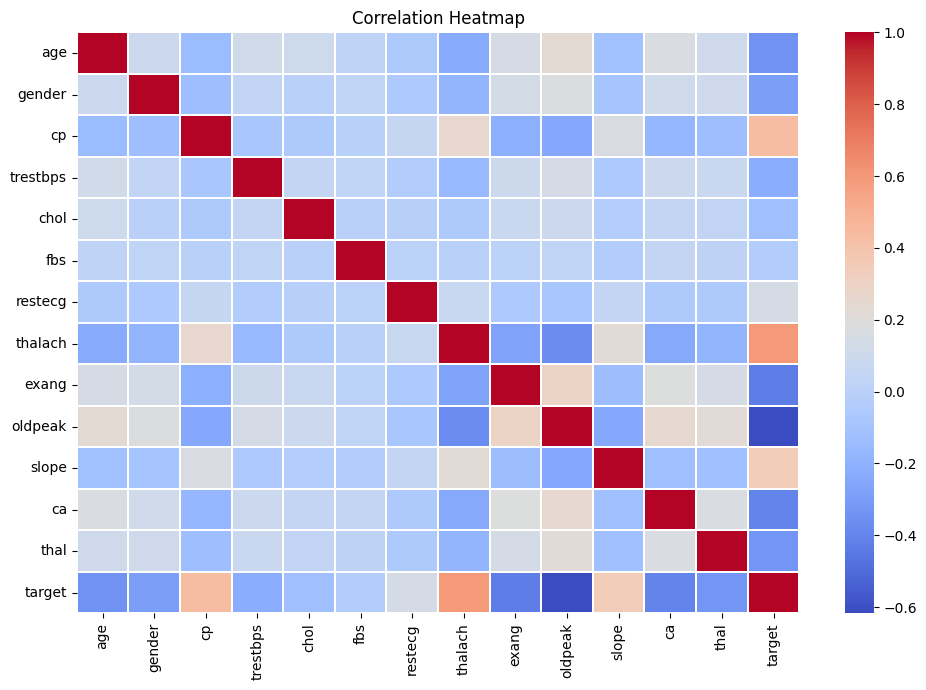

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.to_list()

plt.figure(figsize=(10,7))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", annot=False, linewidths=0.2)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ⚙️ Data Preprocessing & Feature Engineering

## Separate Features and Target

In [12]:
target_col = "target"

X_raw = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(int)

## Handle Missing Values

In [13]:
for c in X_raw.columns:
    if X_raw[c].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(X_raw[c]):
            X_raw[c] = X_raw[c].fillna(X_raw[c].median())
        else:
            X_raw[c] = X_raw[c].fillna(X_raw[c].mode().iloc[0])

## Identify Categorical and Numeric Features

In [14]:
categorical_cols = []
numeric_cols = []

for c in X_raw.columns:
    if pd.api.types.is_numeric_dtype(X_raw[c]):
        if X_raw[c].nunique() <= 10 and c not in ["age", "chol", "trestbps", "thalach", "oldpeak"]:
            categorical_cols.append(c)
        else:
            numeric_cols.append(c)
    else:
        categorical_cols.append(c)

## One-Hot Encoding

In [15]:
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

print("After encoding, X shape:", X.shape)

After encoding, X shape: (5000, 22)


# 🧠 Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 📏 Feature Scaling

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🤖 Model Training

In [18]:
models = {}

models["Logistic Regression"] = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

models["SVM (RBF)"] = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

models["Random Forest"] = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced_subsample",
    random_state=42
)

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()

scale_pos_weight = neg / pos if pos > 0 else 1.0

models["XGBoost"] = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# 📊 Model Evaluation

In [19]:
def evaluate_model(name, model, scaled=False):

    if scaled:
        model.fit(X_train_scaled, y_train)
        prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        prob = model.predict_proba(X_test)[:,1]

    pred = (prob >= 0.5).astype(int)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, prob)
    }

## Run Model Comparison

In [20]:
results = []

results.append(evaluate_model("Logistic Regression", models["Logistic Regression"], scaled=True))
results.append(evaluate_model("SVM (RBF)", models["SVM (RBF)"], scaled=True))
results.append(evaluate_model("Random Forest", models["Random Forest"]))
results.append(evaluate_model("XGBoost", models["XGBoost"]))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.944,0.960076,0.935185,0.947467,0.986848
1,SVM (RBF),0.946,0.956767,0.942593,0.949627,0.986320
2,Random Forest,0.948,0.958647,0.944444,0.951493,0.988007
3,XGBoost,0.953,0.965974,0.946296,0.956034,0.990898


## 📈 Model Performance Visualization

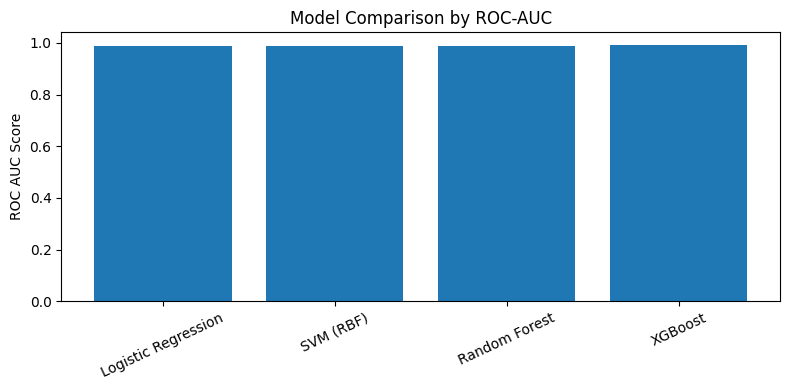

In [21]:
plt.figure(figsize=(8,4))

plt.bar(results_df["Model"], results_df["ROC AUC"])

plt.title("Model Comparison by ROC-AUC")
plt.ylabel("ROC AUC Score")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

## 🏆 Best Model Selection

In [22]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]

print(f"Best model: {best_name}")

Best model: Logistic Regression


## 📉 ROC Curve

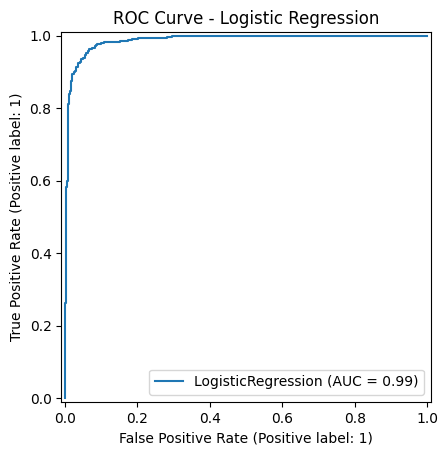

In [23]:
if best_name in ["Logistic Regression", "SVM (RBF)"]:
    best_model.fit(X_train_scaled, y_train)
    RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test)
else:
    best_model.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title(f"ROC Curve - {best_name}")
plt.show()

## 📋 Classification Report

In [24]:
if best_name in ["Logistic Regression", "SVM (RBF)"]:
    print(classification_report(y_test, best_model.predict(X_test_scaled)))
else:
    print(classification_report(y_test, best_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       460
           1       0.96      0.94      0.95       540

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



## 🌳 Feature Importance (Tree Models)

In [25]:
if hasattr(best_model, "feature_importances_"):

    importances = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    print(importances.head(15))

    plt.figure(figsize=(9,5))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title("Top Feature Importances")
    plt.show()

## 🧠 Patient Risk Prediction

In [26]:
def predict_patient_risk(patient_dict, threshold=0.5):

    row = pd.DataFrame([patient_dict])

    for c in X_raw.columns:
        if c not in row.columns:
            row[c] = np.nan

    for c in row.columns:
        if row[c].isna().sum() > 0:
            if c in X_raw.columns and pd.api.types.is_numeric_dtype(X_raw[c]):
                row[c] = row[c].fillna(X_raw[c].median())
            else:
                row[c] = row[c].fillna(X_raw[c].mode().iloc[0])

    row_enc = pd.get_dummies(row, columns=categorical_cols, drop_first=True)

    for col in X.columns:
        if col not in row_enc.columns:
            row_enc[col] = 0

    row_enc = row_enc[X.columns]

    if best_name in ["Logistic Regression", "SVM (RBF)"]:
        row_scaled = scaler.transform(row_enc)
        prob = best_model.predict_proba(row_scaled)[0,1]
    else:
        prob = best_model.predict_proba(row_enc)[0,1]

    pred_class = int(prob >= threshold)

    if prob >= 0.8:
        risk_label = "High Risk"
    elif prob >= 0.5:
        risk_label = "Moderate Risk"
    else:
        risk_label = "Low Risk"

    return pred_class, prob, risk_label

## 🧪 Example Prediction

In [28]:
def user_input_patient():
    patient_name = input("Enter patient name: ")
    age = int(input("Enter age (years): "))
    gender = int(input("Enter gender (0=Female, 1=Male): "))
    cp = int(input("Enter chest pain type (1-4): "))
    trestbps = int(input("Enter resting blood pressure (mm Hg): "))
    chol = int(input("Enter serum cholesterol (mg/dl): "))
    fbs = int(input("Enter fasting blood sugar > 120 mg/dl (0=No, 1=Yes): "))
    restecg = int(input("Enter resting ECG results (0-2): "))
    thalach = int(input("Enter maximum heart rate achieved: "))
    exang = int(input("Exercise induced angina (0=No, 1=Yes): "))
    oldpeak = float(input("ST depression induced by exercise relative to rest: "))
    slope = int(input("Slope of the peak exercise ST segment (1-3): "))
    ca = int(input("Number of major vessels colored by fluoroscopy (0-3): "))
    thal = int(input("Thalassemia (1=Normal, 2=Reversible, 3=Fixed): "))

    return {
        "Name": patient_name,
        "age": age,
        "gender": gender,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }

# gather the inputs and then use the predictor
example_patient = user_input_patient()
pred, prob, label = predict_patient_risk(example_patient)

output = [(example_patient["Name"], pred, prob, label)]
output_df = pd.DataFrame(
    output,
    columns=["Name", "Predicted Target", "Probability", "Risk Level"]
)
output_df

ValueError: invalid literal for int() with base 10: ''